In [1]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import math
from torchmetrics.classification import MulticlassAccuracy
from timeit import default_timer as timer
from tqdm.notebook import tqdm
import sys

In [2]:
BATCH_SIZE = 32
RANDOM_SEED = 42

In [3]:
device = "cpu" if torch.cuda.is_available() else "cpu"
device

'cpu'

## importing the data from torch datasets 

In [4]:
train_data = datasets.FashionMNIST(
    root="data",
    train=True,
    transform=ToTensor(),
    target_transform=None,
    download= True
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    transform=ToTensor(),
    target_transform=None,
    download= True
)

In [5]:
len(train_data), len(test_data)

(60000, 10000)

In [6]:
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [7]:
class_name = train_data.classes
print(f"the image [0] is: {class_name[label]}")

the image [0] is: Ankle boot


## turning the data into iterables using torch dataloader

In [8]:
train_data_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)
test_data_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE)
train_data_loader, test_data_loader

(<torch.utils.data.dataloader.DataLoader at 0x11ad19930e0>,
 <torch.utils.data.dataloader.DataLoader at 0x11ad19fce10>)

## iterating thro the data loader

In [9]:
train_features, train_labels = next(iter(train_data_loader))
train_features.shape, train_labels.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

## visualizing the data images

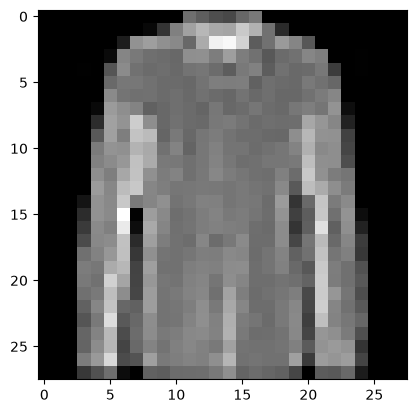

Label: 6


In [10]:
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.show()
print(f"Label: {label}")

In [11]:
train_data.class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

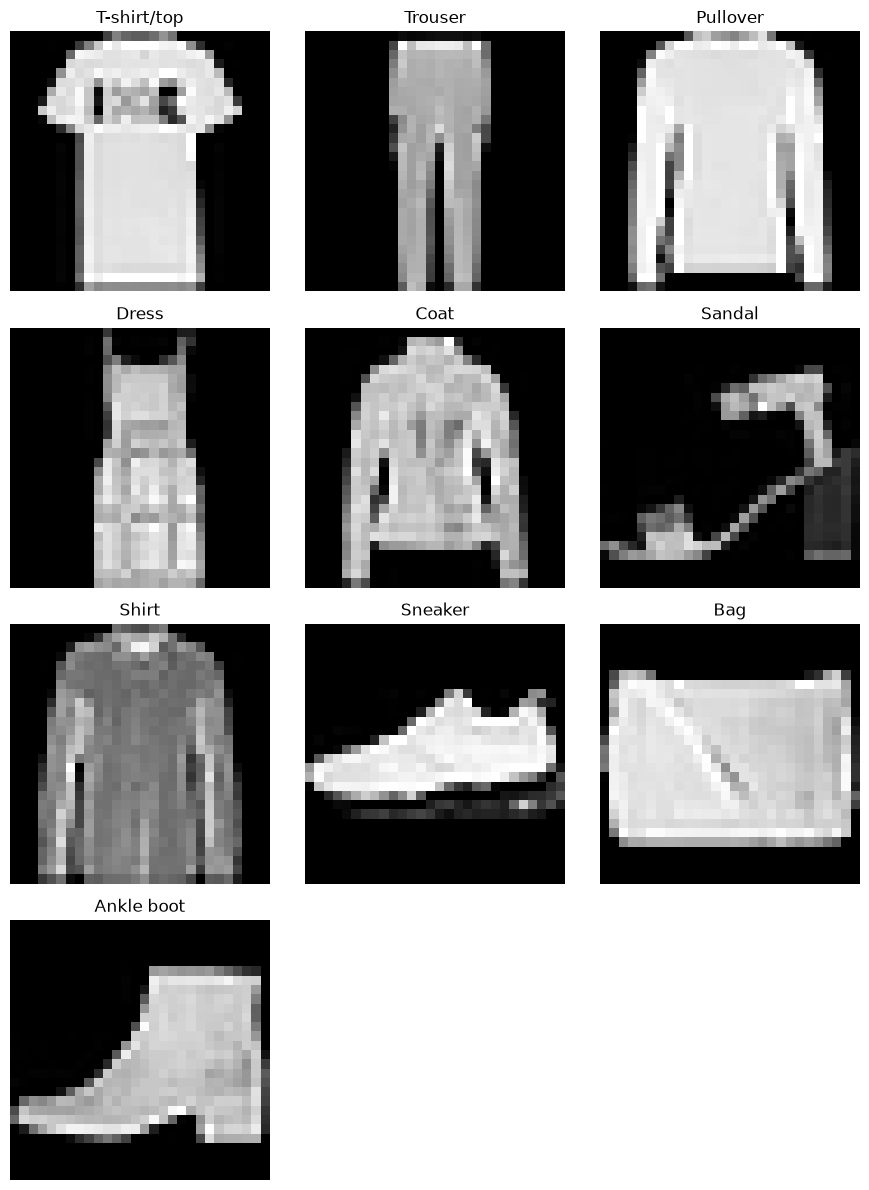

In [12]:
# 1. Grab one representative sample per class
image_list = []
labels_list = []

# Map class names to their numerical indices
idx_to_class = {v: k for k, v in train_data.class_to_idx.items()}

for class_name, target_idx in train_data.class_to_idx.items():
    # Find the first index in train_labels matching this class
    idx = (train_labels == target_idx).nonzero(as_tuple=True)[0][0].item()

    image_list.append(train_features[idx].squeeze())
    labels_list.append(class_name)

# 2. Compute dynamic grid dimensions (e.g., 10 classes -> 3x4 or 2x5)
n_images = len(image_list)
cols = 3
rows = math.ceil(n_images / cols)

# 3. Plot the grid
plt.figure(figsize=(cols * 3, rows * 3))

for i, (img, label_name) in enumerate(zip(image_list, labels_list)):
    plt.subplot(rows, cols, i + 1)

    # Convert PyTorch tensor to NumPy/CPU if needed
    if hasattr(img, "cpu"):
        img = img.cpu()

    plt.imshow(img, cmap="gray")
    plt.title(label_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

i cant even recognize this is a bag lol

## building model [1]

In [13]:
x = train_features[0]

In [14]:
len(train_labels)

32

In [15]:
class ComputerVisionModel(nn.Module):
    def __init__(self, input_features, output_features, hidden_units):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )

    def forward(self, x):
        return self.layer_stack(x)

cv_model = ComputerVisionModel(input_features=28*28, output_features=len(class_name), hidden_units=8).to(device)

In [16]:
# checking the shape of the output and input matching
x_dummy = torch.rand([1,1,28,28]).to(device)
cv_model(x_dummy).shape

torch.Size([1, 10])

### instantiating loss function and optimizer for the model

In [17]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(cv_model.parameters(), lr=.01)
acc = MulticlassAccuracy(num_classes=10).to(device)

### creating a function to track time

In [18]:
def train_time(start: float,
               end: float,
               device: torch.device = None):
    total_time = end - start
    print(f"total training time {total_time:.3f} on the {device}")
    return total_time

### creating the training loop

In [19]:
torch.cuda.manual_seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

start_time = timer()
epochs = 3

for epoch in tqdm(range(epochs), desc=f"overall epochs"):

    train_loss_ = 0

    cv_model.train()
    for X, y in tqdm(train_data_loader, leave=False, desc=f"training epoch {epoch+1}"):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()

        train_logits = cv_model(X)
        train_pred = torch.softmax(train_logits, dim=1).argmax(dim=1)

        train_loss = loss_fn(train_logits, y)

        train_loss.backward()

        optimizer.step()
        train_loss_+= train_loss.item()

    train_loss_ /= len(train_data_loader)

    cv_model.eval()
    with torch.inference_mode():

        test_loss_ = 0
        test_acc = 0

        for X, y in  tqdm(test_data_loader, leave=False, desc=f"testing epoch {epoch+1}"):
            X, y = X.to(device), y.to(device)
            test_logits = cv_model(X)

            test_loss = loss_fn(test_logits, y)

            test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

            test_loss_ += test_loss.item()
            test_acc += acc(test_pred, y)

        test_loss_ /= len(test_data_loader)
        test_acc /= len(test_data_loader)

end_time = timer()

train_time(start=start_time, end=end_time, device=str(next(cv_model.parameters()).device))

overall epochs:   0%|          | 0/3 [00:00<?, ?it/s]

training epoch 1:   0%|          | 0/1875 [00:00<?, ?it/s]

testing epoch 1:   0%|          | 0/313 [00:00<?, ?it/s]

training epoch 2:   0%|          | 0/1875 [00:00<?, ?it/s]

testing epoch 2:   0%|          | 0/313 [00:00<?, ?it/s]

training epoch 3:   0%|          | 0/1875 [00:00<?, ?it/s]

testing epoch 3:   0%|          | 0/313 [00:00<?, ?it/s]

total training time 28.558 on the cpu


28.557575999999926

In [20]:
train_loss_, test_loss_, test_acc.item()*100

(0.4820136498570442, 0.519848787270415, 80.81213235855103)

In [21]:
X.shape

torch.Size([16, 1, 28, 28])